# Evaluate stim ttl timing relative to Npx channels

## Imports

In [73]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import os
from tkinter import Tk
from tkinter import filedialog
import sys
sys.path.append(r'C:\Users\cgomezg\Documents\GitHub\SpikeGLX_Datafile_Tools\Python')
from DemoReadSGLXData.readSGLX import readMeta, SampRate, makeMemMapRaw, GainCorrectOBX, GainCorrectIM, GainCorrectNI

## Functions

In [22]:
def load_ch_excerpt(bin_full_path, tStart=0, tEnd = None, chanList = None):
    # tStart and tEnd are given in seconds
    # chanList should be a list []
    # Read metadata
    meta = readMeta(bin_full_path);
    sRate = SampRate(meta);
    firstSamp = int(sRate*tStart);
    if tEnd is None:
        last_time = float(meta['fileTimeSecs'])
        lastSamp = int(sRate*last_time)
    else:
        lastSamp = int(sRate*tEnd)

    rawData = makeMemMapRaw(bin_full_path, meta);
    selectData = rawData[chanList, firstSamp:lastSamp+1];

    # Scale data according to its type
    if meta['typeThis'] == 'imec':
        # apply gain correction and convert to uV
        convData = 1e6*GainCorrectIM(selectData, chanList, meta); # 1e6 to convert to uV
    elif meta['typeThis'] == 'obx':
        convData = 1e3*GainCorrectOBX(selectData, chanList, meta); # 1e3 to convert to mV
    else:
        # apply gain correction and convert to mV
        convData = 1e3*GainCorrectNI(selectData, chanList, meta); # 1e3 to convert to mV

    tDat = np.arange(firstSamp, lastSamp+1, dtype='uint64')
    tDat = tDat/sRate      # plot time axis in sec
    
    return convData, tDat, sRate

## Load data

In [3]:
# Specify full path for Opx and Npx bin data
obx_full_path = Path("M:\StimDM\M296\M296_3_g0\M296_3_g0_t0.obx0.obx.bin")
npx_full_path = Path("M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\M296_3_g0_t0.imec0.ap.bin")

# Load ttl event times
ttl_times_path = rf"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0"
tlt_times_file_name = rf"Stims_form_M296_3_updated.csv"
ttl_times_file = Path(ttl_times_path, tlt_times_file_name)
ttl_times_df = pd.read_csv(ttl_times_file)

## Plot Npx channel and stim ttl

In [82]:
# Define Npx and Obx chans to plot
npx_chans = [50]
obx_chans = [4]

# Define saving folder, check if it exists
save_folder = rf"M:\StimDM\M296\M296_3_g0\M296_3_g0_imec0\catgt_M296_3_g0"
save_folder = os.path.join(save_folder, "stim_ttl_check")
os.makedirs(save_folder, exist_ok=True)

In [83]:
# Define correction factors
correct_dict = {'tr100ms':33, 'tr200ms':40, 'tr400ms':49, 'tr600ms':57, 'tr800ms':66, 'tr1s':76, 'tr2s':86, 'tr4s':94, 'tr150ms':102, }

Displaying first trial.


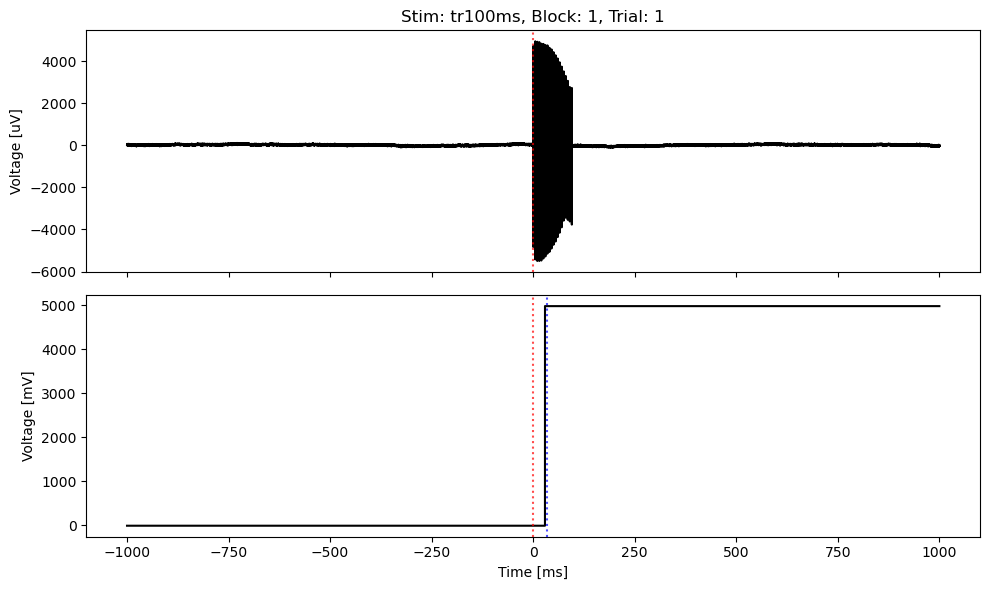

Displaying first trial.


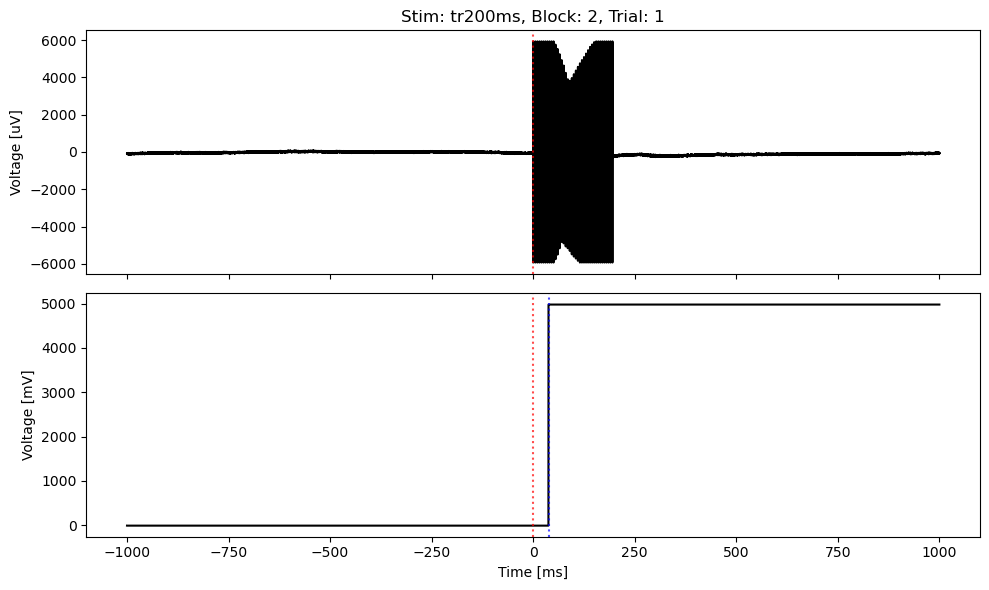

Displaying first trial.


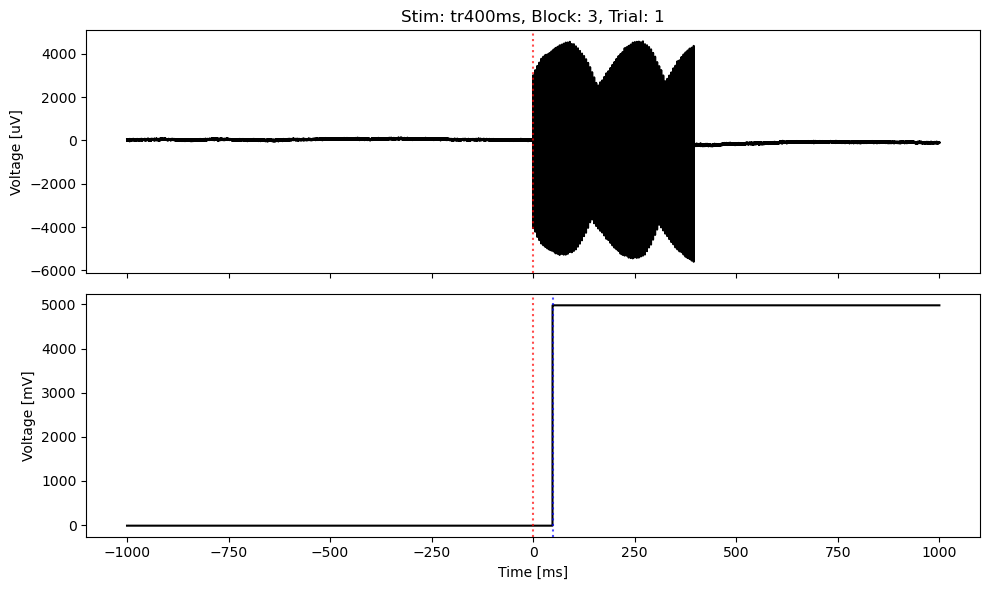

Displaying first trial.


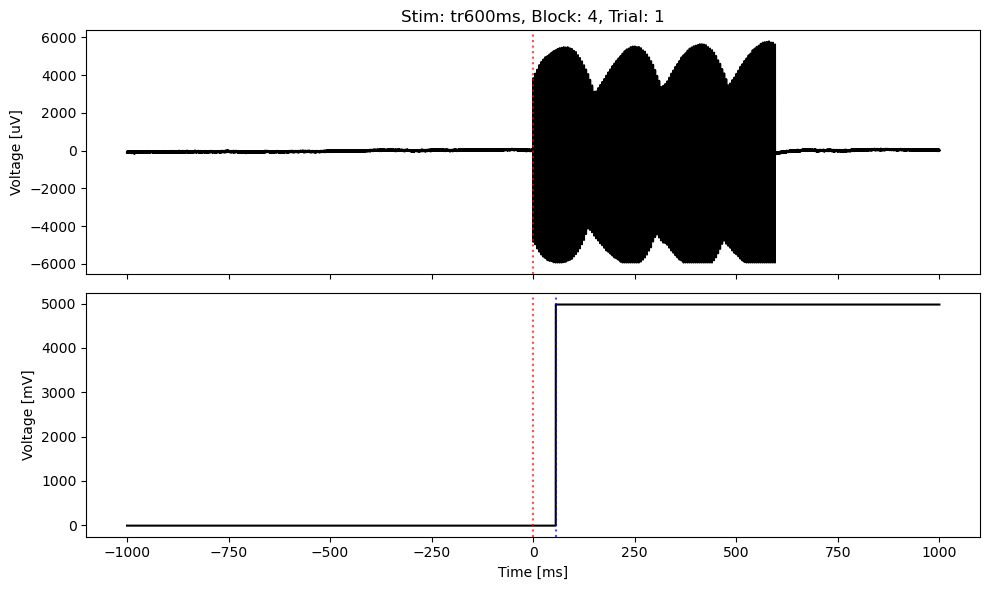

Displaying first trial.


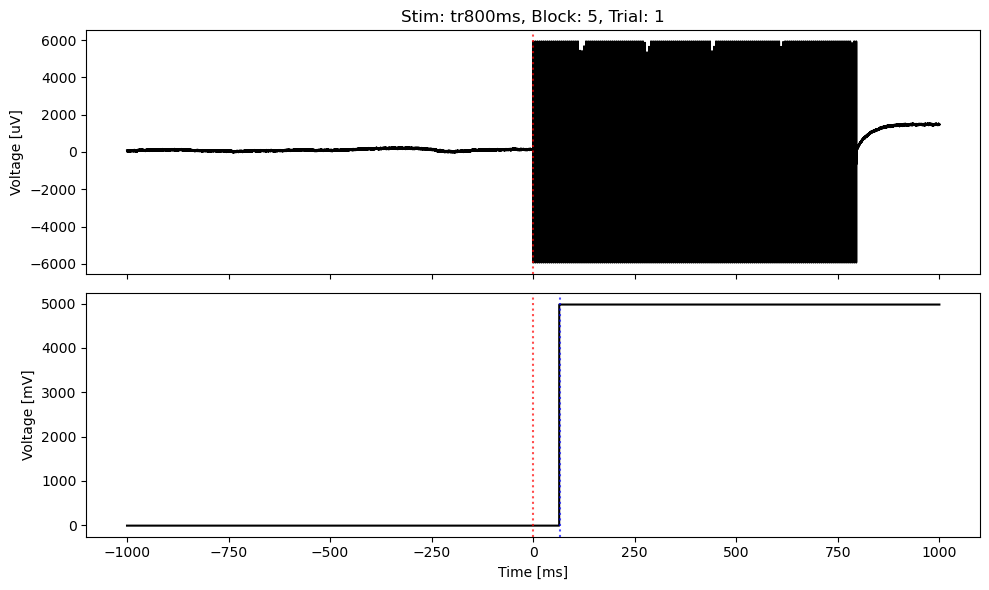

Displaying first trial.


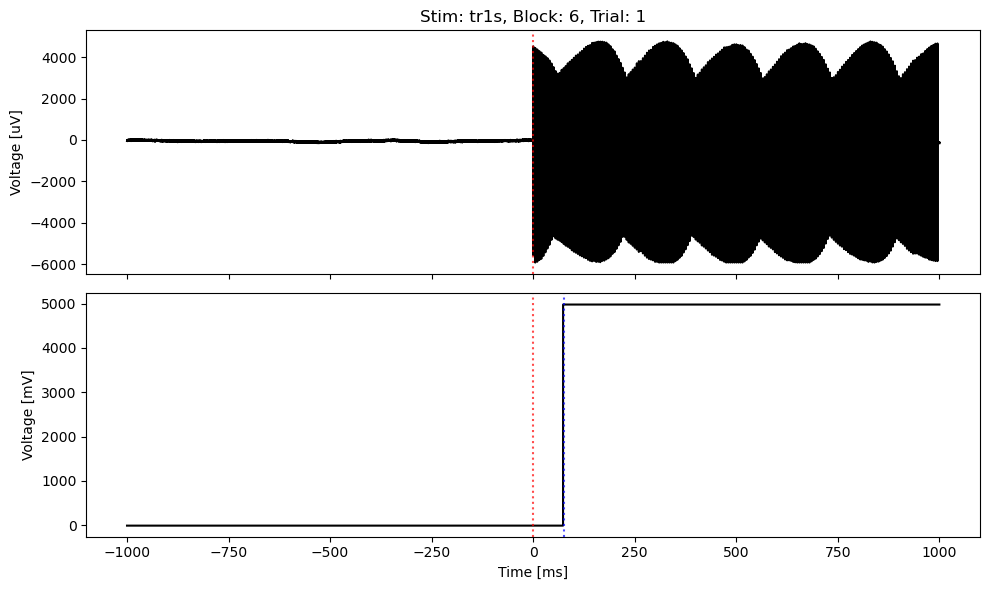

Displaying first trial.


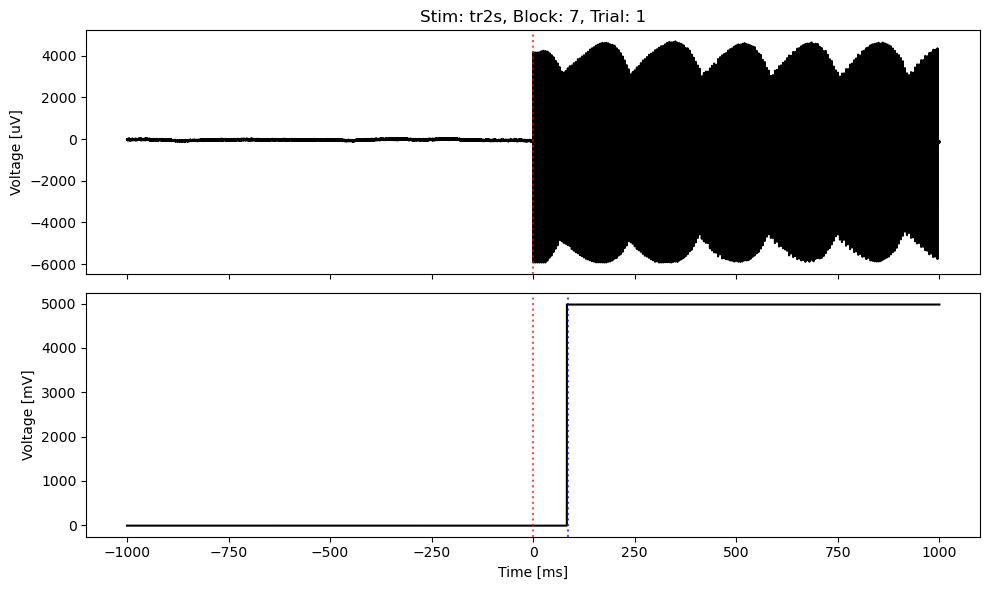

Displaying first trial.


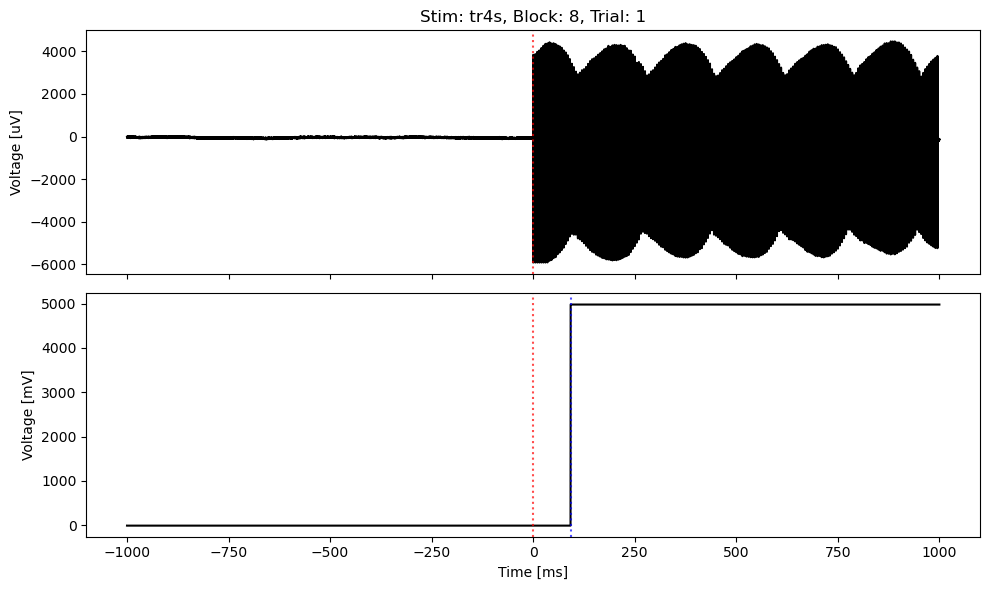

Displaying first trial.


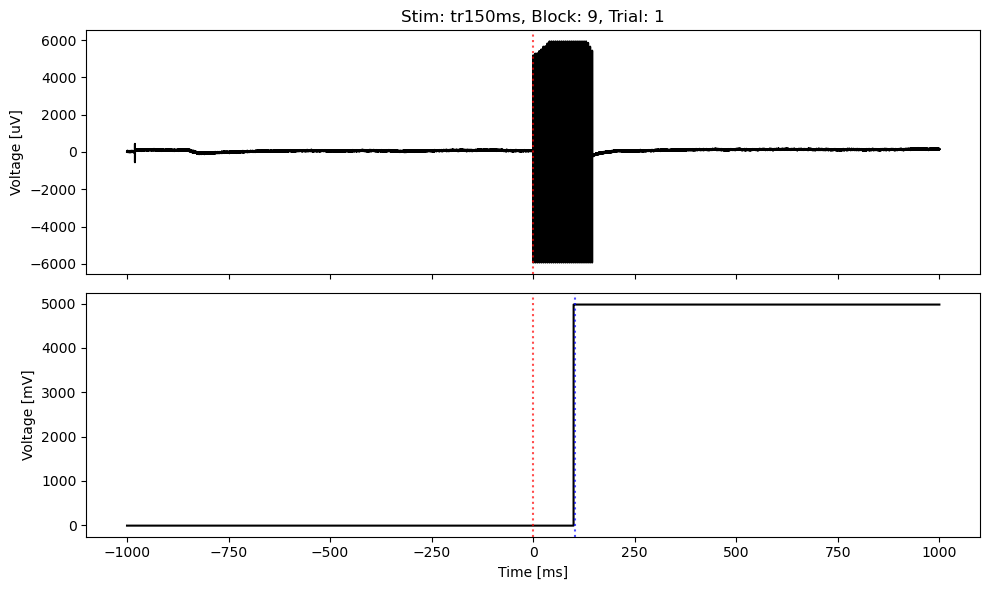

In [84]:
# Plot in a loop
seen_labels = set() # Initialize a set to track which labels have been displayed
for row in ttl_times_df.itertuples(index=True):
    # Set start and end times according to ttl pulse times
    current_ttl_onset = row.s_timesP
    tst = current_ttl_onset - 1
    tnd = current_ttl_onset + 1
    # Load Npx data snippet
    npx_snippet, npt_snippet = load_ch_excerpt(npx_full_path, tStart=tst, 
                                                 tEnd = tnd, chanList = npx_chans);
    # Load Obx data snippet
    obx_snippet, obt_snippet = load_ch_excerpt(obx_full_path, tStart=tst, 
                                                 tEnd = tnd, chanList = obx_chans);

    # Convert absolute time to -1, +1 (onset = 0)
    rel_npt = npt_snippet - current_ttl_onset
    rel_obt = obt_snippet - current_ttl_onset

    # Plot current snippet
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(rel_npt * 1000, npx_snippet[0, :], color='black')
    ax[0].set_ylabel("Voltage [uV]")
    ax[0].set_title(f"Stim: {row.s_names}, Block: {row.block}, Trial: {row.trial}")

    # Plot onset
    ax[0].axvline(x=0, color='red', linestyle=':', alpha=0.7)
    
    ax[1].plot(rel_obt * 1000, obx_snippet[0, :], color='black')
    ax[1].set_xlabel("Time [ms]")
    ax[1].set_ylabel("Voltage [mV]")

    # Plot onset
    ax[1].axvline(x=0, color='red', linestyle=':', alpha=0.7)

    # Plot onset of artifact in npx
    current_correctf = correct_dict[row.s_names]
    ax[1].axvline(x=current_correctf, color='blue', linestyle=':', alpha=0.7)
    #ax[1].set_xticks([-1, 0, 1])
    
    plt.tight_layout()

    # Save every plot to your save_folder
    save_name = os.path.join(save_folder, f"ttl_align_pulse_{row.s_names}_{row.block}_{row.trial}.png")
    fig.savefig(save_name)

    # Display only the first example for each stim type
    if row.s_names not in seen_labels:
        print("Displaying first trial.")
        plt.show() 
        seen_labels.add(row.s_names) # Mark this label as seen
    # Close the figure to optimize RAM
    plt.close(fig)

## Save correction factors

In [85]:
cfile_name = "ttl_correction_factors.txt"
cfull_path = os.path.join(save_folder, cfile_name)

with open(cfull_path, "w") as file:
    json.dump(correct_dict, file, indent=4)

Fin